# Notebook to make Figure 6: Analytic toy model $\sigma_{\rm meas}$ vs. fraction of $\mathbf{p}_T<0.05$

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D
import seaborn as sns 
sns.set_palette('colorblind')

## Setup

Load data

In [2]:
savename = '../data/toymodel_badfit_repeated_pvalue_dists.json'
with open(savename, "r") as f:
    pvals_dict = json.load(f)

Misc.

In [3]:
# Test statistics to look at
Ts = ['minimum', 'maximum', 'fraction $x>1.5$']

# Function to get fraction of p-values < 0.05
def get_frac(x, thr=0.05): 
    return sum(x<thr) / len(x)

## Make figure

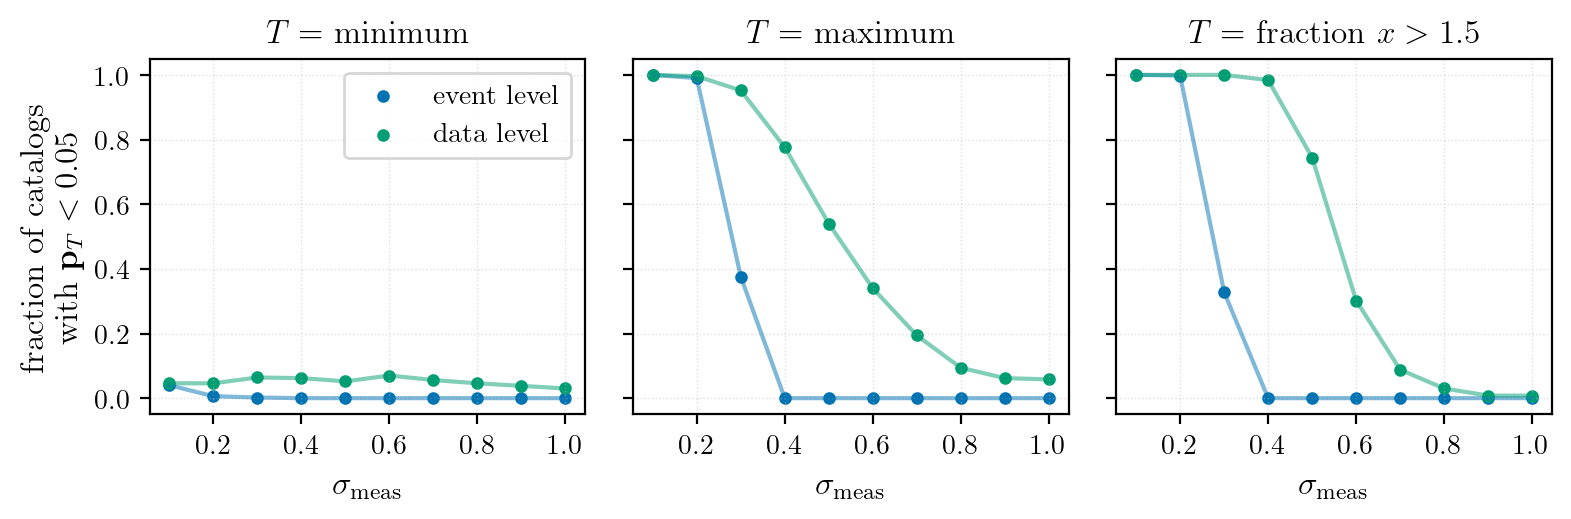

In [4]:
fig, axes = plt.subplots(1,3,figsize=(8,2.7), sharex=True, sharey=True)

# Cycle through test statistics
for ax, k in zip(axes.flatten(), Ts):

    # get the sigma_meas values
    sigma_meas_arr = [float(s) for s in pvals_dict.keys()]
    
    # get the fraction of p < 0.05 for each sigma_meas
    bad_frac_event_lvl_arr = [get_frac(np.asarray(pvals_dict[s]['event-level'][k])) for s in pvals_dict.keys()]
    bad_frac_data_lvl_arr = [get_frac(np.asarray(pvals_dict[s]['data-level'][k]))for s in pvals_dict.keys()]

    # Plot against each other
    ax.plot(sigma_meas_arr, bad_frac_event_lvl_arr, color='C0', alpha=0.5)
    ax.plot(sigma_meas_arr, bad_frac_data_lvl_arr, color='C2',  alpha=0.5)
    ax.scatter(sigma_meas_arr, bad_frac_event_lvl_arr, color='C0', marker='.', s=50, label='event level')
    ax.scatter(sigma_meas_arr, bad_frac_data_lvl_arr, color='C2', marker='.', s=50, label='data level')

    ax.set_xlabel(r'$\sigma_{\rm meas}$', fontsize=12)
    ax.set_title(fr'$T=$ {k}')

    ax.grid(color='silver', alpha=0.5, ls=':')

axes[0].set_ylabel('fraction of catalogs \n' + r'with $\mathbf{p}_T < 0.05$', fontsize=12)
axes[0].legend()
plt.tight_layout()
plt.savefig('figure_06.png', dpi=300, bbox_inches='tight')
plt.show()